In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import json

from CMR_IA.utils import wmse

cmr.analysis.setup_notebook()

SAVEFIG = False
RUNCMR = False
SAVERES = False
if SAVERES and not RUNCMR:
    print("Warning: SAVERES is ignored when RUNCMR is False; existing results are loaded instead.")

## Load Stimuli and Semantic Matrix

In [2]:
# Load study and test data
df_study = pd.read_parquet("data/simu2b_study.parquet")
df_test = pd.read_parquet("data/simu2b_test.parquet")

In [3]:
# Inspect study data
df_study

,session,subj,list,trial,word1,word2,itemno1,itemno2
0,0,101,0,-1,formal,positive,422,759
1,0,101,0,0,skin,careful,930,158
2,0,101,0,1,upon,miss,1086,643
3,0,101,0,2,single,tradition,923,1059
4,0,101,0,3,prove,airport,793,35
...,...,...,...,...,...,...,...,...
53275,110,1150,7,54,forget,pocket,419,752
53276,110,1150,7,55,patient,plastic,723,742
53277,110,1150,7,56,justice,lord,544,593
53278,110,1150,7,57,society,caught,940,165


In [4]:
# Inspect test data
df_test

,session,subj,list,trial,word1,word2,itemno1,itemno2,type,lag,forward
0,0,101,0,-1,waste,degree,1112,269,rearranged,2,0
1,0,101,0,0,needed,able,673,2,rearranged,1,1
2,0,101,0,1,single,clean,923,193,rearranged,3,1
3,0,101,0,2,train,useful,1061,1089,rearranged,2,1
4,0,101,0,3,knees,various,552,1095,rearranged,5,1
...,...,...,...,...,...,...,...,...,...,...,...
53275,110,1150,7,54,opposite,period,703,729,intact,-1,0
53276,110,1150,7,55,card,limited,155,582,rearranged,2,1
53277,110,1150,7,56,soft,measure,941,620,rearranged,3,0
53278,110,1150,7,57,dark,fall,256,373,intact,-1,0


In [5]:
# Load semantic matrix
sem_mat = np.load("data/simu2b_smat.npy")

## Run CMR-IA

In [6]:
# Read PSO results and set parameters
params = cmr.load_params("2b")
params

{'beta_enc': 0.165159,
 'beta_rec': None,
 'beta_cue': 0.504416,
 'beta_rec_post': 0.594594,
 'beta_distract': 0.452162,
 'beta_enc_inpair': None,
 's_fc': 0.000933,
 's_cf': 0.0,
 'phi_s': 0.0,
 'phi_d': 0.0,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 6.279106,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1.0,
 'c_thresh_assoc': 1.038428,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': None,
 'eta': None,
 'omega': None,
 'alpha': None,
 'lamb': None,
 'c_thresh': None,
 'ban_recall': None,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 50,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'gamma_fc': 0.046091,
 'gamma_cf': 0.0}

In [7]:
# Run model or load saved results
if RUNCMR:
    df_simu = cmr.run_norm_recog_multi_sess(params, df_study, df_test, sem_mat, design="Osth")
    df_simu = df_simu.merge(df_test, on=["session", "list", "itemno1", "itemno2"])
    if SAVERES:
        df_simu.to_parquet("data/simu2b_result.parquet")
else:
    df_simu = pd.read_parquet("data/simu2b_result.parquet")
df_simu

100%|██████████| 111/111 [10:32<00:00,  5.69s/it]

CMR Time: 632.1517632007599


,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag,forward
0,0,0,1112,269,0,0,0.054789,0.090473,0.491080,101,-1,waste,degree,rearranged,2,0
1,0,0,673,2,1,0,0.058925,0.056958,0.500492,101,0,needed,able,rearranged,1,1
2,0,0,923,193,0,0,0.034671,0.061181,0.493373,101,1,single,clean,rearranged,3,1
3,0,0,1061,1089,1,0,0.053196,0.036051,0.504286,101,2,train,useful,rearranged,2,1
4,0,0,552,1095,0,0,0.041780,0.055205,0.496644,101,3,knees,various,rearranged,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53275,110,7,703,729,1,0,0.027001,0.023352,0.500912,1150,54,opposite,period,intact,-1,0
53276,110,7,155,582,0,0,0.023700,0.028029,0.498918,1150,55,card,limited,rearranged,2,1
53277,110,7,941,620,1,0,0.025179,0.024617,0.500141,1150,56,soft,measure,rearranged,3,0
53278,110,7,256,373,1,0,0.029409,0.026144,0.500816,1150,57,dark,fall,intact,-1,0


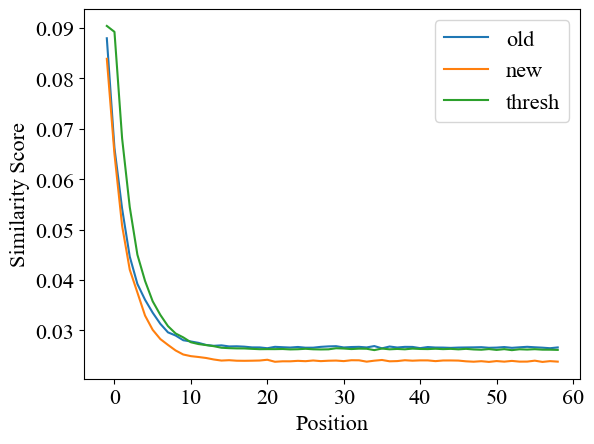

In [8]:
# Plot csim and threshold by trial position
old_csim_pos = df_simu.query("type == 'intact'").groupby("trial").csim.mean()
old_pos = np.unique(df_simu.query("type == 'intact'").trial.to_numpy())
new_csim_pos = df_simu.query("type == 'rearranged'").groupby("trial").csim.mean()
new_pos = np.unique(df_simu.query("type == 'rearranged'").trial.to_numpy())
cthresh_pos = df_simu.groupby("trial").thresh.mean()
pos = np.unique(df_simu.trial.to_numpy())

plt.plot(old_pos, old_csim_pos, label="old")
plt.plot(new_pos, new_csim_pos, label="new")
plt.plot(pos, cthresh_pos, label="thresh")
plt.xlabel("Position")
plt.ylabel("Similarity Score")
plt.legend()
plt.show()

## Analysis

In [9]:
# Add old/new and correct columns
df_simu["old"] = df_simu.apply(lambda x: 1 if x["type"] == "intact" else 0, axis=1)
df_simu["correct"] = df_simu["s_resp"] == df_simu["old"]
df_simu

,session,list,itemno1,itemno2,s_resp,s_rt,csim,thresh,prob,subj,trial,word1,word2,type,lag,forward,old,correct
0,0,0,1112,269,0,0,0.054789,0.090473,0.491080,101,-1,waste,degree,rearranged,2,0,0,True
1,0,0,673,2,1,0,0.058925,0.056958,0.500492,101,0,needed,able,rearranged,1,1,0,False
2,0,0,923,193,0,0,0.034671,0.061181,0.493373,101,1,single,clean,rearranged,3,1,0,True
3,0,0,1061,1089,1,0,0.053196,0.036051,0.504286,101,2,train,useful,rearranged,2,1,0,False
4,0,0,552,1095,0,0,0.041780,0.055205,0.496644,101,3,knees,various,rearranged,5,1,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53275,110,7,703,729,1,0,0.027001,0.023352,0.500912,1150,54,opposite,period,intact,-1,0,1,True
53276,110,7,155,582,0,0,0.023700,0.028029,0.498918,1150,55,card,limited,rearranged,2,1,0,True
53277,110,7,941,620,1,0,0.025179,0.024617,0.500141,1150,56,soft,measure,rearranged,3,0,0,False
53278,110,7,256,373,1,0,0.029409,0.026144,0.500816,1150,57,dark,fall,intact,-1,0,1,True


### Overall HR and FAR

In [10]:
# Get yes rate and compute HR/FAR
df_hrfar = df_simu.groupby(["session", "type"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_hrfar = df_hrfar.pivot(index="session", columns="type", values="yes_rate").reset_index()
df_hrfar["hr"] = df_hrfar["intact"]
df_hrfar["far"] = 1 - df_hrfar["rearranged"]
df_hrfar

type,session,intact,rearranged,hr,far
0,0,0.512500,0.804167,0.512500,0.195833
1,1,0.558333,0.770833,0.558333,0.229167
2,2,0.500000,0.800000,0.500000,0.200000
3,3,0.533333,0.795833,0.533333,0.204167
4,4,0.491667,0.779167,0.491667,0.220833
...,...,...,...,...,...
106,106,0.508333,0.808333,0.508333,0.191667
107,107,0.562500,0.775000,0.562500,0.225000
108,108,0.520833,0.791667,0.520833,0.208333
109,109,0.558333,0.787500,0.558333,0.212500


In [11]:
# Melt HR/FAR for plotting
df_hrfar_plot = pd.melt(df_hrfar, id_vars=["session"], value_vars=["hr", "far"], var_name="type", value_name="yes_rate")
df_hrfar_plot

,session,type,yes_rate
0,0,hr,0.512500
1,1,hr,0.558333
2,2,hr,0.500000
3,3,hr,0.533333
4,4,hr,0.491667
...,...,...,...
217,106,far,0.191667
218,107,far,0.225000
219,108,far,0.208333
220,109,far,0.212500


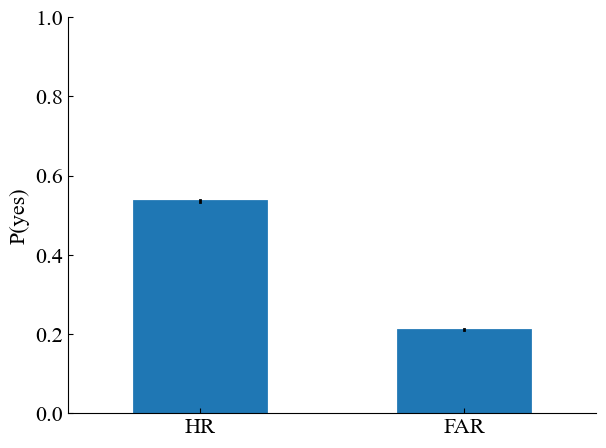

In [12]:
# Plot HR and FAR bar chart
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

sns.barplot(
    data=df_hrfar_plot,
    x="type",
    y="yes_rate",
    width=0.5,
    errorbar="se",
    ax=ax,
    err_kws={"lw": 2, "color": "black"},
    facecolor="C0",
    edgecolor="C0",
    lw=2,
)

ax.set_xticks(ticks=[0, 1], labels=["HR", "FAR"])
ax.set_yticks(ticks=np.arange(0, 1.1, 0.2))
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

ax.spines[["right", "top"]].set_visible(False)
ax.set(xlabel=None, ylabel="P(yes)")

if SAVEFIG:
    ax.set(ylabel=None)
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.savefig(f"figures/simu2b_hrfar.pdf")
plt.show()

### Far with Lag

In [13]:
# Compute FAR by lag for lure items
df_lure = df_simu.query("type == 'rearranged'").copy()
df_farlag = df_lure.groupby(["session", "lag"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_farlag["far"] = 1 - df_farlag["yes_rate"]
df_farlag

,session,lag,yes_rate,far
0,0,1,0.833333,0.166667
1,0,2,0.833333,0.166667
2,0,3,0.770833,0.229167
3,0,4,0.708333,0.291667
4,0,5,0.875000,0.125000
...,...,...,...,...
550,110,1,0.833333,0.166667
551,110,2,0.708333,0.291667
552,110,3,0.750000,0.250000
553,110,4,0.729167,0.270833


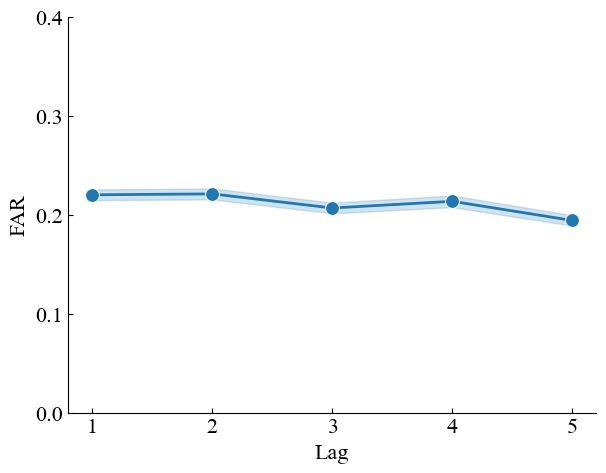

In [14]:
# Plot FAR by lag
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

sns.lineplot(
    data=df_farlag,
    x="lag",
    y="far",
    marker="o",
    markersize=10,
    errorbar="se",
    err_style="band",
    ax=ax,
    linewidth=2,
    linestyle="-",
)

ax.set_xticks(ticks=np.arange(1, 6))
ax.set_yticks(ticks=np.arange(0, 0.41, 0.1))
ax.set_xlim(0.8, 5.2)
ax.set_ylim(0, 0.4)
ax.set(xlabel="Lag", ylabel="FAR")
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
ax.spines[["right", "top"]].set_visible(False)

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig(f"figures/simu2b_lag.pdf")
plt.show()

In [15]:
# Compute mean csim by lag for lure items
df_farlag_csim = df_lure.groupby(["session", "lag"]).csim.mean().to_frame(name="csim").reset_index()
df_farlag_csim

,session,lag,csim
0,0,1,0.028149
1,0,2,0.029697
2,0,3,0.027556
3,0,4,0.029079
4,0,5,0.026861
...,...,...,...
550,110,1,0.024816
551,110,2,0.029642
552,110,3,0.025807
553,110,4,0.025504


In [16]:
# Compute lag-csim correlation per session
sessions = df_farlag_csim.session.unique()
corrs = []
for sess in sessions:
    df_sess = df_farlag_csim.query("session == @sess")
    lag = df_sess["lag"].to_numpy()
    csim = df_sess["csim"].to_numpy()
    # do correlation
    corr = sp.stats.pearsonr(lag, csim)
    corrs.append(corr)
np.mean(corrs), np.std(corrs)

(0.18810830637752235, 0.5121481792853008)

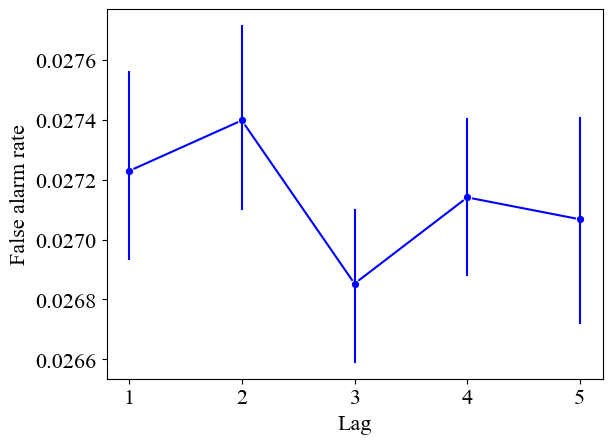

In [17]:
# Plot mean csim by lag
sns.lineplot(
    data=df_farlag_csim,
    x="lag",
    y="csim",
    color="blue",
    marker="o",
    err_style="bars",
)
# plt.ylim(0, 0.1)
plt.xlim(0.8, 5.2)
plt.xticks(np.arange(1, 6))
# plt.yticks(np.arange(0, 0.11, 0.01))
plt.xlabel("Lag")
plt.ylabel("False alarm rate")
plt.show()

## Error Check

In [18]:
# Load ground truth
with open("data/simu2b_gt.json") as f:
    gt = json.load(f)
hr_gt = np.array(gt["hr"])
hr_std_gt = np.array(gt["hr_std"])
far_gt = np.array(gt["far"])
far_std_gt = np.array(gt["far_std"])
hr_gt, hr_std_gt, far_gt, far_std_gt

(array(0.53661864),
 array(0.16334876),
 array([0.21428165, 0.2174274 , 0.21721617, 0.21166567, 0.20021831]),
 array([0.14578635, 0.15351747, 0.16036269, 0.14002328, 0.13892722]))

In [19]:
# Extract simulated HR and FAR
hr = df_hrfar_plot.query("type == 'hr'").yes_rate.mean()
far = df_farlag.groupby("lag").far.mean().to_numpy()
hr, far

(0.5364489489489489,
 array([0.21996997, 0.22090841, 0.20664414, 0.2134009 , 0.19406907]))

In [ ]:
# Calculate error
err = 5 * wmse(hr_gt, hr, hr_std_gt) + wmse(far_gt, far, far_std_gt)
err

0.008500895224892259

## Slope Check

In [21]:
# Import regression tools for slope analysis
import statsmodels.formula.api as smf
from scipy import stats

In [22]:
# Inspect FAR by lag data
df_farlag

,session,lag,yes_rate,far
0,0,1,0.833333,0.166667
1,0,2,0.833333,0.166667
2,0,3,0.770833,0.229167
3,0,4,0.708333,0.291667
4,0,5,0.875000,0.125000
...,...,...,...,...
550,110,1,0.833333,0.166667
551,110,2,0.708333,0.291667
552,110,3,0.750000,0.250000
553,110,4,0.729167,0.270833


In [23]:
# Fit OLS slope of far ~ lag per session
sessions = df_farlag.session.unique()
slopes = []
for sess in sessions:
    df_tmp = df_farlag.query("session == @sess").copy()
    res = smf.ols(formula="far ~ lag", data=df_tmp).fit()
    slopes.append(res.params["lag"])

In [24]:
# Summarize slope distribution
np.mean(slopes), np.std(slopes), stats.sem(slopes)

(-0.005930930930930936, 0.01827839117149133, 0.00174277621736139)

In [25]:
# T test
t_stat, p_val = stats.ttest_1samp(slopes, 0)
t_stat, p_val

(-3.403151174458029, 0.0009300372668708093)